   customer_id  age  gender         region   contract_type  tenure_months  \
0            1   56  Female           Asia  Month-to-Month             42   
1            2   69    Male         Europe        Two Year             23   
2            3   46  Female  South America  Month-to-Month             64   
3            4   32  Female  North America  Month-to-Month             38   
4            5   60    Male           Asia        One Year             57   

  internet_service  monthly_charges  data_usage_gb  avg_call_duration_minutes  \
0               5G            49.49         244.86                       4.92   
1              DSL            92.74         211.98                       4.04   
2               5G            26.95         179.35                       6.92   
3      Fiber Optic            69.06           5.00                       4.19   
4      Fiber Optic            64.55         193.71                       4.09   

   support_calls  late_payments  payment_method  s

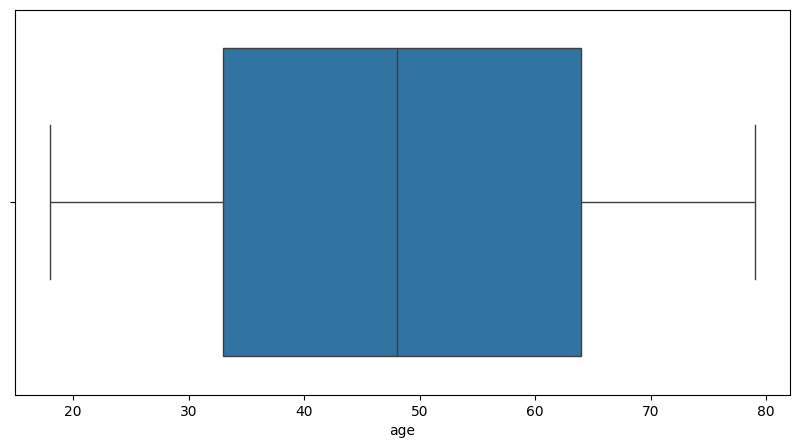

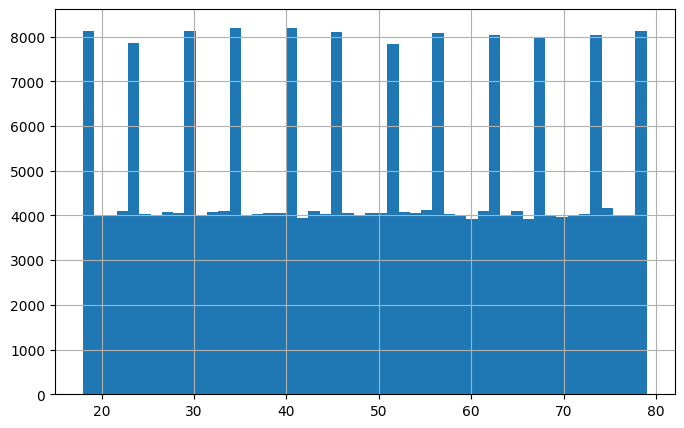

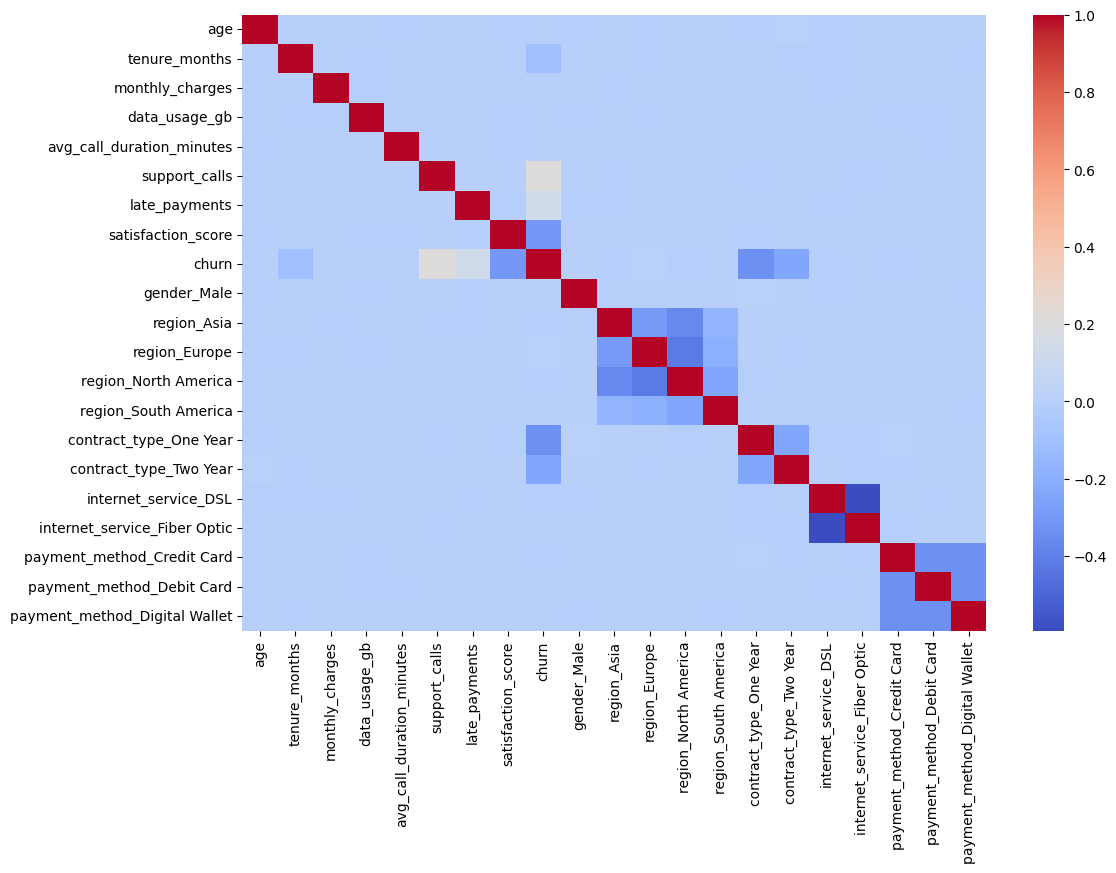

Accuracy: 0.8194535233363839
Prediction: [1]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("customer_churn_dataset_250k.csv")


print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())


df = df.drop(['customer_id'], axis=1)


df = pd.get_dummies(df, drop_first=True)


plt.figure(figsize=(10,5))
sns.boxplot(x=df.iloc[:,0])
plt.show()


col = df.columns[0]

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df[col] >= lower) & (df[col] <= upper)]


plt.figure(figsize=(8,5))
df[col].hist(bins=50)
plt.show()


plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()


churn_yes = df[df['churn'] == 1]
churn_no = df[df['churn'] == 0]
churn_no_sample = churn_no.sample(len(churn_yes), random_state=42)

new_df = pd.concat([churn_yes, churn_no_sample])


X = new_df.drop('churn', axis=1)
y = new_df['churn']

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))


sample = X_test[0].reshape(1, -1)
print("Prediction:", model.predict(sample))